In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import firls, firwin, firwin2, freqz, lfilter
from google.colab import drive

In [3]:
drive.mount("/content/drive", force_remount=True)
folder = "/content/drive/My Drive/Colab Notebooks/Цифровая обработка сигналов/"

Mounted at /content/drive


# 1

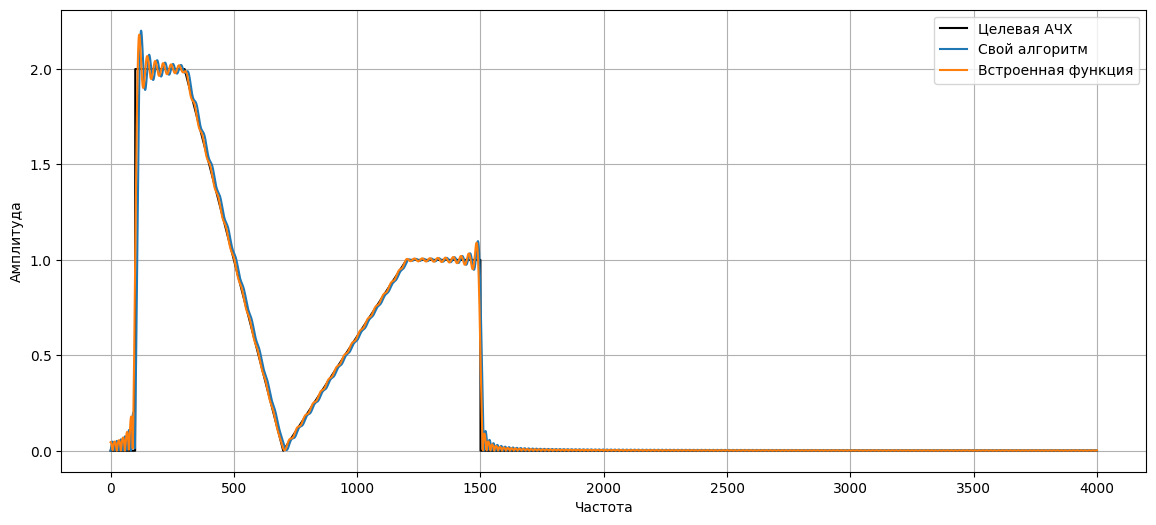

In [4]:
fs = 8000 # частота дискретизации
L = 2 # продолжительность сигнала
N = 501 # порядок фильтра

# целевая АЧХ
def H_d(f):
    f = np.array(f)
    result = np.zeros_like(f, dtype=float)
    result = np.where(f < 100, 0.0, result)
    result = np.where((f >= 100) & (f <= 300), 2.0, result)
    result = np.where((f >= 300) & (f <= 700), -f / 200 + 7 / 2, result)
    result = np.where((f >= 700) & (f <= 1200), f / 500 - 7 /5 , result)
    result = np.where((f >= 1200) & (f <= 1500), 1.0, result)
    result = np.where(f > 1500, 0.0, result)
    return result


# полосовой фильтр
omega = np.arange(0.0, np.pi, np.pi / N)
frequencies = omega / (2.0 * np.pi / fs)
A_resp_band = H_d(frequencies)

M = (N - 1) // 2
a_matrix = np.asmatrix(A_resp_band[0: N]).transpose()
F_matrix = np.asmatrix(np.zeros((N, M)))
M_range = np.arange(M, 0, -1)

for i in range(N - 1):
  F_matrix[i, 0: M] = 2.0 * np.sin(omega[i + 1] * M_range)

# импульсная характеристика фильтра, МНК
h_matrix = (
    np.linalg.inv(F_matrix.transpose() * F_matrix)
    * F_matrix.transpose()
    * a_matrix
)
h_half = np.asarray(h_matrix.transpose())[0]
h = np.zeros(N)
h[0: M] = h_half
h[M + 1: N] = -np.flip(h_half)

f = np.linspace(0.0, fs / 2.0, L * fs // 2)

bandpass_impl = h
w_impl, resp_impl = freqz(bandpass_impl, 1, f, fs=fs)

bandpass_lib = firls(N, f, H_d(f), fs=fs)
w_lib, resp_lib = freqz(bandpass_lib, 1, f, fs=fs)


plt.figure(figsize=(14, 6))
plt.plot(f, H_d(f), label="Целевая АЧХ", color="black")
plt.plot(w_impl, abs(resp_impl), label="Свой алгоритм")
plt.plot(w_lib, abs(resp_lib), label="Встроенная функция")
plt.xlabel("Частота")
plt.ylabel("Амплитуда")
plt.grid()
plt.legend()
plt.show()

# 2

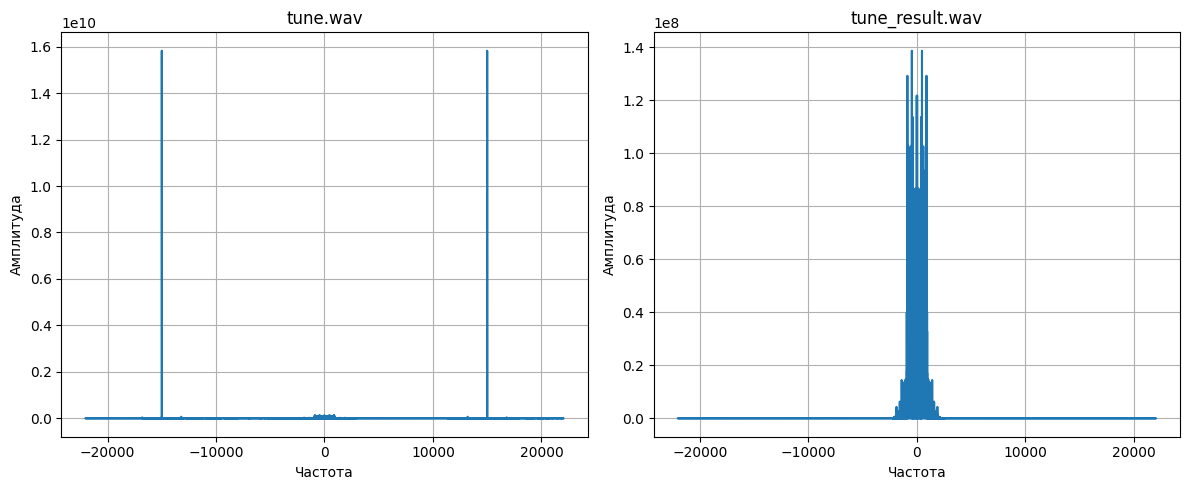

In [ ]:
fs, signal = wavfile.read(folder + "tune.wav")

cutoff_frequency = fs / 30 # частота среза
N = 101 # порядок фильтра


spectrum = np.fft.fft(signal)
amplitude = np.abs(spectrum)
frequency = np.fft.fftfreq(signal.shape[0], 1 / fs)


# КИХ-фильтр нижних частот с использованием оконной функции
b = firwin(N, cutoff_frequency, window="blackman", fs=fs, pass_zero="lowpass")

filtered_signal = lfilter(b, 1.0, signal.astype(np.int16))
filtered_spectrum = np.fft.fft(filtered_signal)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(frequency, amplitude)
axes[0].set_title("tune.wav")
axes[0].set_ylabel("Амплитуда")
axes[0].set_xlabel("Частота")
axes[0].grid()
axes[1].plot(frequency, np.abs(filtered_spectrum))
axes[1].set_title("tune_result.wav")
axes[1].set_ylabel("Амплитуда")
axes[1].set_xlabel("Частота")
axes[1].grid()
plt.tight_layout()
plt.show()

# fig, axes = plt.subplots(2, 1, figsize=(12, 6))
# axes[0].plot(signal[25000: 28000])
# axes[0].set_title("tune.wav")
# axes[0].set_ylabel("Амплитуда")
# axes[0].set_xlabel("Время")
# axes[0].grid()
# axes[1].plot(filtered_signal[25000: 28000])
# axes[1].set_title("tune_result.wav")
# axes[1].set_ylabel("Амплитуда")
# axes[1].set_xlabel("Время")
# axes[1].grid()
# plt.tight_layout()
# plt.show()


filtered_signal = np.real(np.fft.ifft(filtered_spectrum)).astype(np.int16)
wavfile.write("tune_result.wav", fs, filtered_signal)

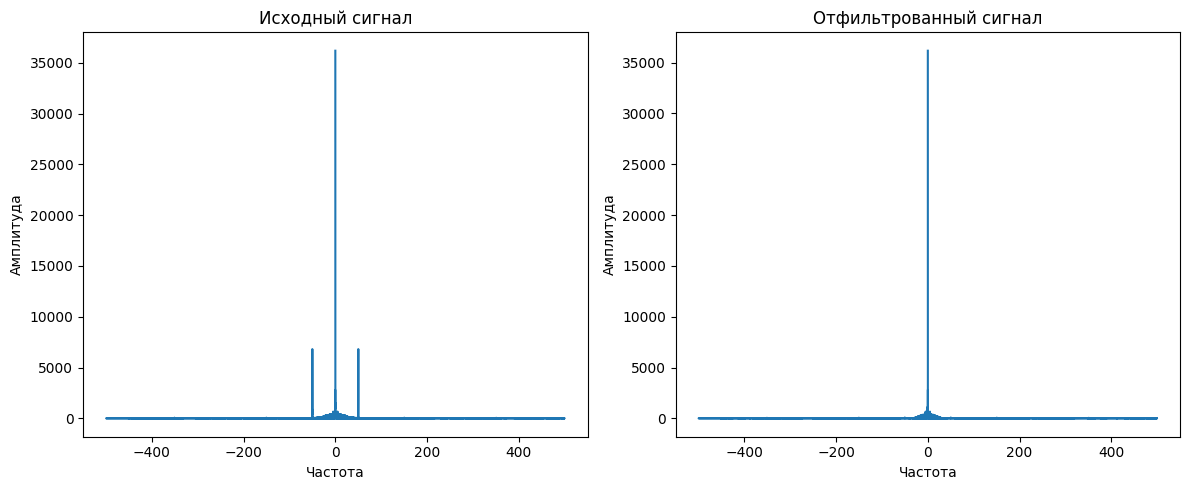

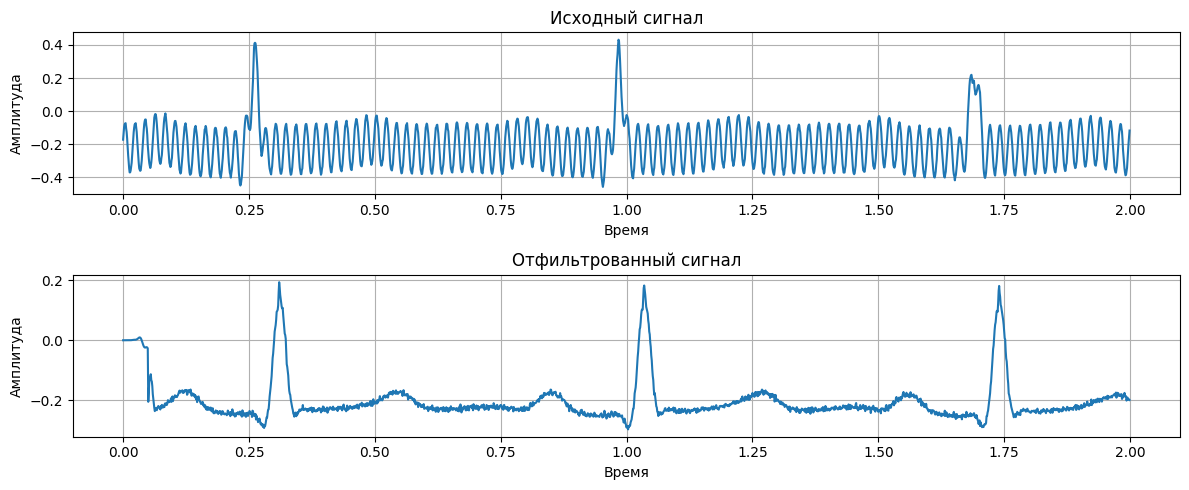

In [ ]:
with open(folder + "ecg.dat") as f:
    data = f.readlines()
    n = len(data)

time = np.ndarray(n) # массив для временных меток (ось X)
signal = np.ndarray(n) # массив для значений сигнала (ось Y)

for i in range(n):
    s = data[i].split()
    time[i] = float(s[0]) # временная метка
    signal[i] = float(s[1]) # амплитуда сигнала


N = 101 # порядок фильтра
cutoff_frequencies = [0.05, 0.14]
# режекторный КИХ-фильтр с использованием оконной функции
b = firwin(N, cutoff_frequencies, pass_zero="bandstop", window="blackman")
signal_filtered = lfilter(b, 1.0, signal)

# амплитудный спектр
sampling_period = time[1]

spectrum = np.fft.fft(signal)
frequency = np.fft.fftfreq(len(signal_filtered), sampling_period)
filtered_spectrum = np.fft.fft(signal_filtered)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(frequency, np.abs(spectrum))
axes[0].set_title("Исходный сигнал")
axes[0].set_ylabel("Амплитуда")
axes[0].set_xlabel("Частота")
axes[1].plot(frequency, np.abs(filtered_spectrum))
axes[1].set_title("Отфильтрованный сигнал")
axes[1].set_ylabel("Амплитуда")
axes[1].set_xlabel("Частота")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].set_title("Исходный сигнал")
axes[0].plot(time[0: 2000], signal[0: 2000])
axes[0].set_ylabel("Амплитуда")
axes[0].set_xlabel("Время")
axes[0].grid()
axes[1].set_title("Отфильтрованный сигнал")
axes[1].plot(time[0: 2000], signal_filtered[0: 2000])
axes[1].set_ylabel("Амплитуда")
axes[1].set_xlabel("Время")
axes[1].grid()
plt.tight_layout()
plt.show()

# 3

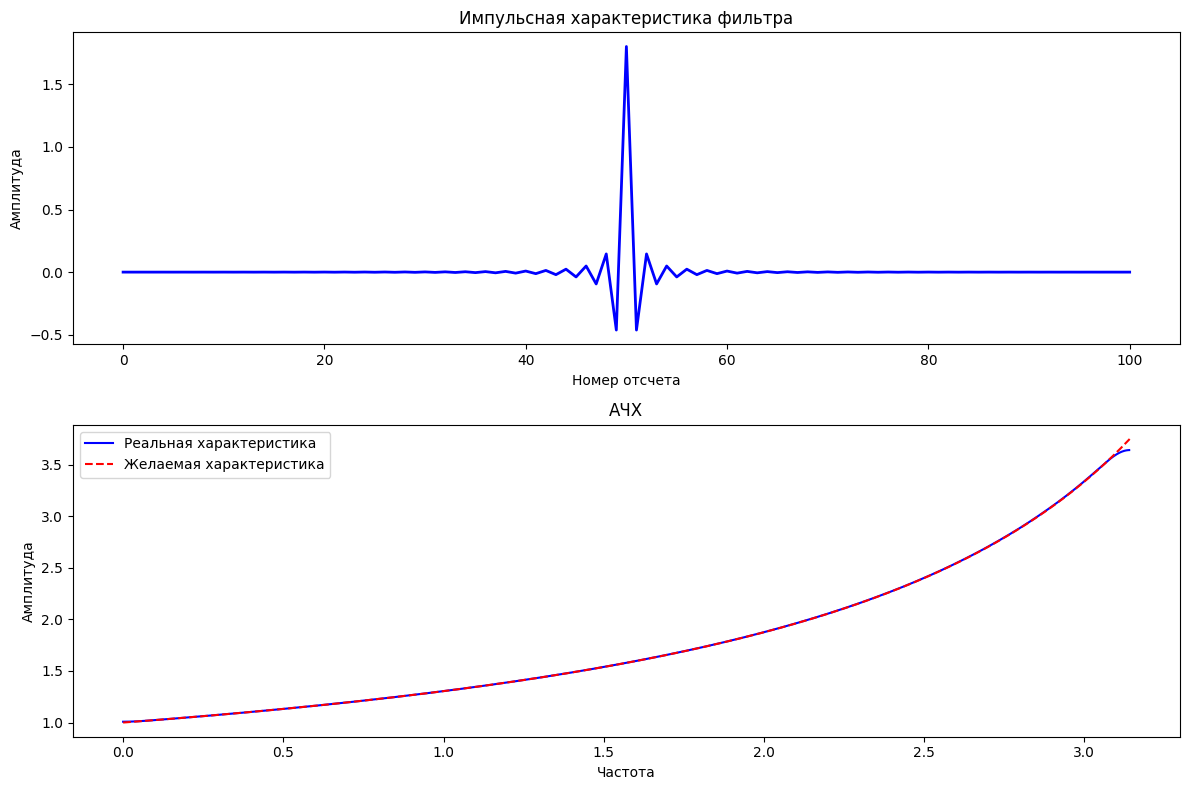

In [ ]:
Fc = 30000
Fs = 44000 # частота дискретизации микрофона
N = 101 # порядок фильтра
w = np.linspace(0, np.pi, 1024)

def H_d(w):
    return 1 / (1 - (Fs * w) / (Fc * 2 * np.pi))

H_desired = H_d(w)


# КИХ-фильтр
h = firwin2(N, w / np.pi, H_desired)

w_filt, H_filt = freqz(h, worN=2048)


plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(h, "b", linewidth=2)
plt.title("Импульсная характеристика фильтра")
plt.xlabel("Номер отсчета")
plt.ylabel("Амплитуда")

plt.subplot(2, 1, 2)
plt.plot(w_filt, np.abs(H_filt), "b", label="Реальная характеристика")
plt.plot(w, H_desired, "r--", label="Желаемая характеристика")

plt.title("АЧХ")
plt.xlabel("Частота")
plt.ylabel("Амплитуда")
plt.legend()
plt.tight_layout()
plt.show()